# Notebook 02 -- Feature Engineering

**Data source:** `main_marts.fct_enrollment_outcomes` (DuckDB)  
**Output:** `data/processed/modeling_data.parquet`  

**Steps:**
1. Load from mart layer
2. Feature selection -- drop keys, labels, and low-signal columns
3. Feature engineering -- derived features informed by EDA
4. Encoding -- target label encoding
5. Train/test split
6. Class imbalance -- document the strategy
7. Save processed dataset

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import os
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

CLASS_COLORS = {
    'Dropout':  '#378ADD',
    'Enrolled': '#D85A30',
    'Graduate': '#639922'
}
CLASS_ORDER = ['Dropout', 'Enrolled', 'Graduate']

os.makedirs('../data/processed', exist_ok=True)

## 1. Load from mart layer

In [2]:
con = duckdb.connect('../data/student_dropout.duckdb')

df = con.execute("""
    SELECT
        f.*,
        p.course_name,
        p.attendance_label
    FROM main_marts.fct_enrollment_outcomes f
    LEFT JOIN main_intermediate.int_program_context p
        ON f.program_key = p.program_key
""").df()

con.close()

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape: (4424, 44)
Columns: ['student_key', 'program_key', 'economic_context_key', 'application_mode', 'application_order', 'previous_qualification', 'previous_qualification_grade', 'admission_grade', 'is_scholarship_holder', 'tuition_fees_up_to_date', 'is_debtor', 'age_at_enrollment', 'gender', 'gender_label', 'nationality', 'is_international', 'is_displaced', 'has_special_needs', 'marital_status', 'marital_status_label', 'mothers_qualification', 'fathers_qualification', 'mothers_occupation', 'fathers_occupation', 'unemployment_rate', 'inflation_rate', 'gdp', 'sem1_units_credited', 'sem1_units_enrolled', 'sem1_evaluations', 'sem1_units_approved', 'sem1_grade', 'sem1_units_no_eval', 'sem2_units_credited', 'sem2_units_enrolled', 'sem2_evaluations', 'sem2_units_approved', 'sem2_grade', 'sem2_units_no_eval', 'sem1_approval_rate', 'sem2_approval_rate', 'outcome', 'course_name', 'attendance_label']


## 2. Feature selection

Drop surrogate keys, decoded label columns, and features identified as low-signal in EDA.
Document each decision explicitly.

In [3]:
# Columns to drop and why
drop_cols = {
    # Surrogate keys -- identifiers, not features
    'student_key':            'surrogate key',
    'program_key':            'surrogate key',
    'economic_context_key':   'surrogate key',

    # Decoded label columns -- string versions of integer codes already in the data
    'gender_label':           'string label for gender integer code',
    'marital_status_label':   'string label for marital_status integer code',
    'attendance_label':       'string label for attendance_type integer code',
    'course_name':            'string label for course_id integer code',

    # Low-signal per EDA correlation matrix
    'admission_grade':        'near-zero correlation with all features in EDA',

    # Credited units -- near-identical to enrolled units, adds collinearity
    'sem1_units_credited':    'highly collinear with sem1_units_enrolled',
    'sem2_units_credited':    'highly collinear with sem2_units_enrolled',
}

print("Dropping columns:")
for col, reason in drop_cols.items():
    print(f"  {col:35s} -- {reason}")

df = df.drop(columns=list(drop_cols.keys()))
print(f"\nShape after dropping: {df.shape}")

Dropping columns:
  student_key                         -- surrogate key
  program_key                         -- surrogate key
  economic_context_key                -- surrogate key
  gender_label                        -- string label for gender integer code
  marital_status_label                -- string label for marital_status integer code
  attendance_label                    -- string label for attendance_type integer code
  course_name                         -- string label for course_id integer code
  admission_grade                     -- near-zero correlation with all features in EDA
  sem1_units_credited                 -- highly collinear with sem1_units_enrolled
  sem2_units_credited                 -- highly collinear with sem2_units_enrolled

Shape after dropping: (4424, 34)


## 3. Feature engineering

Derived features informed by EDA findings.

In [4]:
# Units delta: semester 2 minus semester 1 approved
# Captures trajectory -- a student improving vs declining
df['units_approved_delta'] = df['sem2_units_approved'] - df['sem1_units_approved']

# Grade delta: semester 2 minus semester 1 grade
# Captures grade trajectory across semesters
df['grade_delta'] = df['sem2_grade'] - df['sem1_grade']

# Combined approval rate: average of sem1 and sem2
# Single summary of overall approval performance
df['combined_approval_rate'] = (
    df[['sem1_approval_rate', 'sem2_approval_rate']]
    .mean(axis=1)
)

# Financial stress flag: debtor AND tuition not current
# Interaction term capturing compounded financial risk
df['financial_stress'] = (
    (df['is_debtor'] == 1) & (df['tuition_fees_up_to_date'] == 0)
).astype(int)

print("Engineered features added:")
print("  units_approved_delta    -- sem2 minus sem1 units approved (trajectory)")
print("  grade_delta             -- sem2 minus sem1 grade (trajectory)")
print("  combined_approval_rate  -- mean of sem1 and sem2 approval rates")
print("  financial_stress        -- debtor AND tuition not current (interaction)")
print(f"\nShape after engineering: {df.shape}")

Engineered features added:
  units_approved_delta    -- sem2 minus sem1 units approved (trajectory)
  grade_delta             -- sem2 minus sem1 grade (trajectory)
  combined_approval_rate  -- mean of sem1 and sem2 approval rates
  financial_stress        -- debtor AND tuition not current (interaction)

Shape after engineering: (4424, 38)


In [5]:
# Verify engineered features have meaningful signal
eng_features = ['units_approved_delta', 'grade_delta', 'combined_approval_rate', 'financial_stress']

print("Mean engineered feature values by outcome:")
print(df.groupby('outcome')[eng_features].mean().round(3).loc[CLASS_ORDER].to_string())

Mean engineered feature values by outcome:
          units_approved_delta  grade_delta  combined_approval_rate  financial_stress
outcome                                                                              
Dropout                 -0.612       -1.357                   0.358             0.151
Enrolled                -0.261       -0.008                   0.693             0.025
Graduate                -0.055        0.054                   0.934             0.005


## 4. Handle missing values

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print("No missing values found.")
else:
    print("Columns with missing values:")
    print(missing)
    # Approval rates are null when enrolled units = 0 -- fill with 0
    for col in ['sem1_approval_rate', 'sem2_approval_rate', 'combined_approval_rate']:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    print("\nFilled approval rate nulls with 0 (enrolled = 0 implies approved = 0).")
    print(f"Remaining nulls: {df.isnull().sum().sum()}")

Columns with missing values:
sem1_approval_rate        180
sem2_approval_rate        180
combined_approval_rate    180
dtype: int64

Filled approval rate nulls with 0 (enrolled = 0 implies approved = 0).
Remaining nulls: 0


## 5. Encode target

In [7]:
le = LabelEncoder()
le.fit(CLASS_ORDER)  # Fit in explicit order: Dropout=0, Enrolled=1, Graduate=2
df['outcome_encoded'] = le.transform(df['outcome'])

print("Target encoding:")
for cls, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls:10s} -> {code}")

Target encoding:
  Dropout    -> 0
  Enrolled   -> 1
  Graduate   -> 2


## 6. Train/test split

In [9]:
feature_cols = [c for c in df.columns if c not in ['outcome', 'outcome_encoded']]

X = df[feature_cols]
y = df['outcome_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # preserve class proportions in both splits
)

print(f"Train size: {X_train.shape[0]:,}  ({X_train.shape[0]/len(df):.0%})")
print(f"Test size:  {X_test.shape[0]:,}  ({X_test.shape[0]/len(df):.0%})")
print(f"Features:   {X_train.shape[1]}")
print("\nClass distribution in test set:")
for code, cls in enumerate(le.classes_):
    n = (y_test == code).sum()
    print(f"  {cls:10s}: {n:>4}  ({n/len(y_test):.1%})")

Train size: 3,539  (80%)
Test size:  885  (20%)
Features:   37

Class distribution in test set:
  Dropout   :  284  (32.1%)
  Enrolled  :  159  (18.0%)
  Graduate  :  442  (49.9%)


## 7. Class imbalance strategy

Graduate is the majority class at ~50%. Two approaches will be compared in notebook 03:

- `class_weight='balanced'` in sklearn estimators -- adjusts loss function weights inversely proportional to class frequency. No synthetic data generated. Simple and effective for moderate imbalance.
- SMOTE (Synthetic Minority Oversampling Technique) -- generates synthetic samples for minority classes in the training set only. Applied after the train/test split to avoid data leakage.

Both will be evaluated. The model comparison in notebook 04 uses McNemar's test on the same held-out test set regardless of which sampling strategy was used during training.

In [10]:
# Compute class weights for reference (used in notebook 03)
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print("Balanced class weights:")
for code, cls in enumerate(le.classes_):
    print(f"  {cls:10s} (class {code}): {class_weights[code]:.4f}")

print("\nInterpretation: higher weight = penalizes misclassification of that class more.")
print("Enrolled gets the highest weight since it is the minority class.")

Balanced class weights:
  Dropout    (class 0): 1.0375
  Enrolled   (class 1): 1.8577
  Graduate   (class 2): 0.6676

Interpretation: higher weight = penalizes misclassification of that class more.
Enrolled gets the highest weight since it is the minority class.


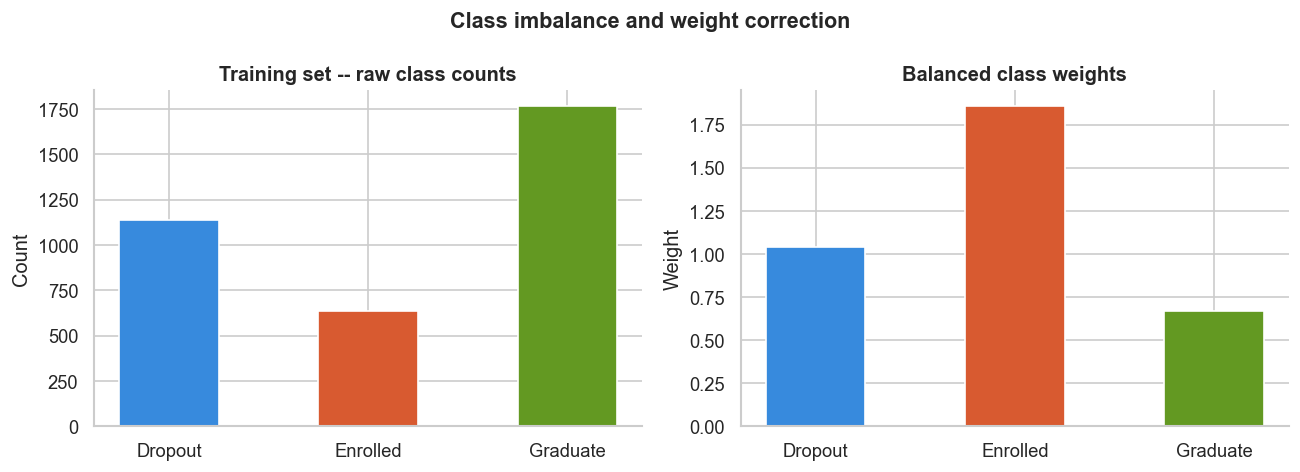

In [11]:
# Visualize class weight effect
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Raw counts
train_counts = pd.Series(y_train).map(dict(enumerate(le.classes_))).value_counts()[CLASS_ORDER]
axes[0].bar(
    CLASS_ORDER,
    train_counts.values,
    color=[CLASS_COLORS[c] for c in CLASS_ORDER],
    width=0.5
)
axes[0].set_title('Training set -- raw class counts', fontweight='bold')
axes[0].set_ylabel('Count')

# Effective weights
axes[1].bar(
    CLASS_ORDER,
    [class_weights[i] for i in range(3)],
    color=[CLASS_COLORS[c] for c in CLASS_ORDER],
    width=0.5
)
axes[1].set_title('Balanced class weights', fontweight='bold')
axes[1].set_ylabel('Weight')

plt.suptitle('Class imbalance and weight correction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/feature_eng_class_weights.png', bbox_inches='tight')
plt.show()

## 8. Save processed dataset

In [12]:
# Save train/test splits as parquet
X_train.to_parquet('../data/processed/X_train.parquet', index=False)
X_test.to_parquet('../data/processed/X_test.parquet', index=False)
y_train.to_frame().to_parquet('../data/processed/y_train.parquet', index=False)
y_test.to_frame().to_parquet('../data/processed/y_test.parquet', index=False)

# Save label encoder classes and class weights for notebook 03
import json
meta = {
    'classes': le.classes_.tolist(),
    'class_weight_dict': {str(k): v for k, v in class_weight_dict.items()},
    'feature_cols': feature_cols,
    'test_size': 0.2,
    'random_state': 42
}
with open('../data/processed/meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print("Saved:")
print("  data/processed/X_train.parquet")
print("  data/processed/X_test.parquet")
print("  data/processed/y_train.parquet")
print("  data/processed/y_test.parquet")
print("  data/processed/meta.json")
print(f"\nFeature count: {len(feature_cols)}")
print(f"Features: {feature_cols}")

Saved:
  data/processed/X_train.parquet
  data/processed/X_test.parquet
  data/processed/y_train.parquet
  data/processed/y_test.parquet
  data/processed/meta.json

Feature count: 37
Features: ['application_mode', 'application_order', 'previous_qualification', 'previous_qualification_grade', 'is_scholarship_holder', 'tuition_fees_up_to_date', 'is_debtor', 'age_at_enrollment', 'gender', 'nationality', 'is_international', 'is_displaced', 'has_special_needs', 'marital_status', 'mothers_qualification', 'fathers_qualification', 'mothers_occupation', 'fathers_occupation', 'unemployment_rate', 'inflation_rate', 'gdp', 'sem1_units_enrolled', 'sem1_evaluations', 'sem1_units_approved', 'sem1_grade', 'sem1_units_no_eval', 'sem2_units_enrolled', 'sem2_evaluations', 'sem2_units_approved', 'sem2_grade', 'sem2_units_no_eval', 'sem1_approval_rate', 'sem2_approval_rate', 'units_approved_delta', 'grade_delta', 'combined_approval_rate', 'financial_stress']
